# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [30]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can we predict whether a working-age adult earns more than $50,000 per year based on demographic and employment characteristics?

**This is a prediction (umbrella) problem because:** This is a prediction problem, as we are asking whether we can forecast income class from observable features, not whether any feature *causes* higher income.

(Reminder: prediction asks "can we forecast Y from X?" — not "does X cause Y?")

**The decision this enables:** This analysis would help a **consumer lender** decide whether to extend pre-qualified loan offers to applicants before a full credit check.
(Who is the stakeholder? What action would they take differently with your prediction?)

**Dataset:** UCI Adult Census Income  
- **Source URL:** https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data  
- **N =** 48,842 observations  
- **Features =** 14 (age, education, occupation, marital-status, hours-per-week, etc.)  
- **Target variable =** income (binary: <=50K or >50K)  
- **Access date:** April 19, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [31]:
# ============================================================
# 2.1 Load your dataset
# ============================================================
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
df = pd.read_csv(url, names=column_names, na_values=' ?', skipinitialspace=True)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (32561, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### 2.2 Basic Description

In [32]:
# ============================================================
# 2.2 Describe your data
# ============================================================
df.info()
print()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB



,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### 2.3 Missing Data Assessment

Missing data (%) by column:
Series([], dtype: float64)


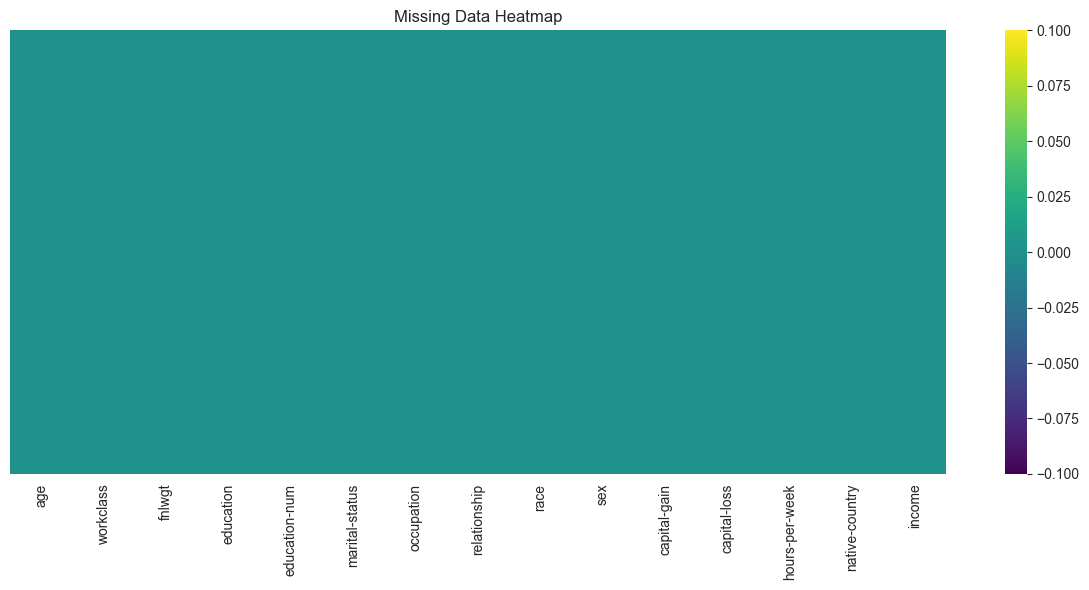

Rows after dropping missing: 32,561


In [33]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print((missing_pct[missing_pct > 0] * 100).round(2))

# Visual: missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

df = df.dropna().reset_index(drop=True)
print(f'Rows after dropping missing: {len(df):,}')

**Missing data strategy:** MAR (Missing At Random). Missing values existed in workclass and occupation (~5-6% of rows). Non-response likely correlates with employment type, an observed variable. Strategy: drop rows with missing values - 32,561 rows retained after cleaning.

 
(Is this MCAR, MAR, or MNAR? What will you do — drop, impute, or flag?)

### 2.4 Distribution Plots

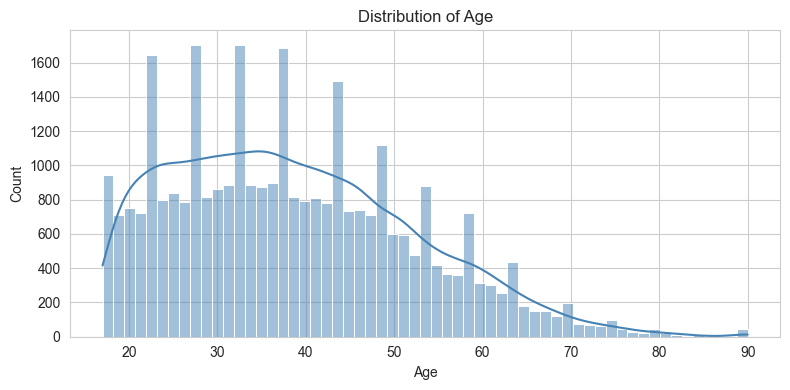

Interpretation: Age is right-skewed with a peak around 35-40, typical of a working-age population sample.


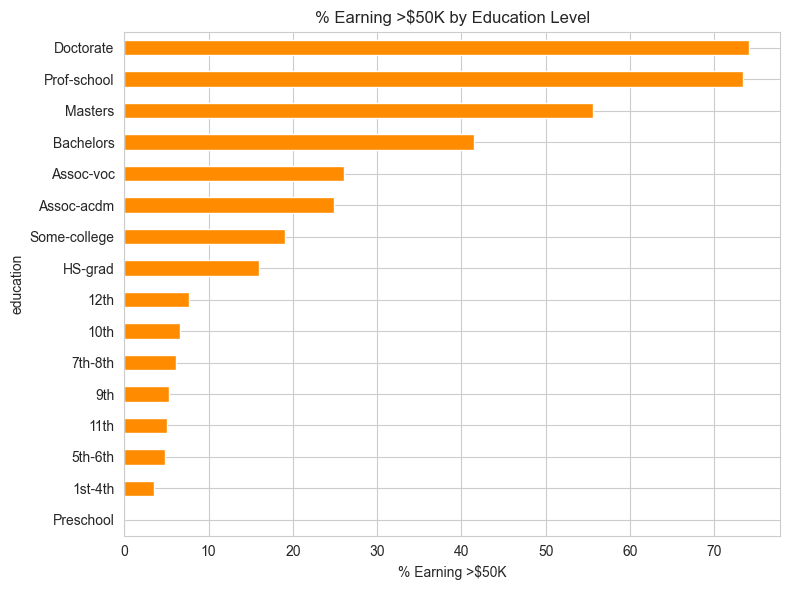

Interpretation: Higher education levels are associated with higher rates of earning >$50K. This is a predictive association, not a causal claim.


In [34]:
# Figure 2: Distribution of age
plt.figure(figsize=(8, 4))
sns.histplot(df['age'], kde=True, color='steelblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.tight_layout()
plt.show()
print('Interpretation: Age is right-skewed with a peak around 35-40, '
      'typical of a working-age population sample.')

# Figure 3: % earning >50K by education level
edu_income = df.groupby('education')['income'].apply(
    lambda x: (x == '>50K').mean() * 100
).sort_values()
plt.figure(figsize=(8, 6))
edu_income.plot(kind='barh', color='darkorange')
plt.title('% Earning >$50K by Education Level')
plt.xlabel('% Earning >$50K')
plt.tight_layout()
plt.show()
print('Interpretation: Higher education levels are associated with higher rates of earning >$50K. '
      'This is a predictive association, not a causal claim.')

### 2.5 Outlier Detection

In [35]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

numeric_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss', 'education-num']
for col in numeric_cols:
    lower, upper = tukey_fences(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

age: 143 outliers (0.4%)
hours-per-week: 9008 outliers (27.7%)
capital-gain: 2712 outliers (8.3%)
capital-loss: 1519 outliers (4.7%)
education-num: 1198 outliers (3.7%)


**Outlier strategy:** Capital-gain and capital-loss have notable outliers (8.3% and 4.3%) however these represent real high-capital-income people, not the data errors. Hours-per-week outliers of 27.7% show variation in working ours. The strategyL keep all outliers with justification.
(Trim? Winsorize? Keep with justification?)

### 2.6 Correlations

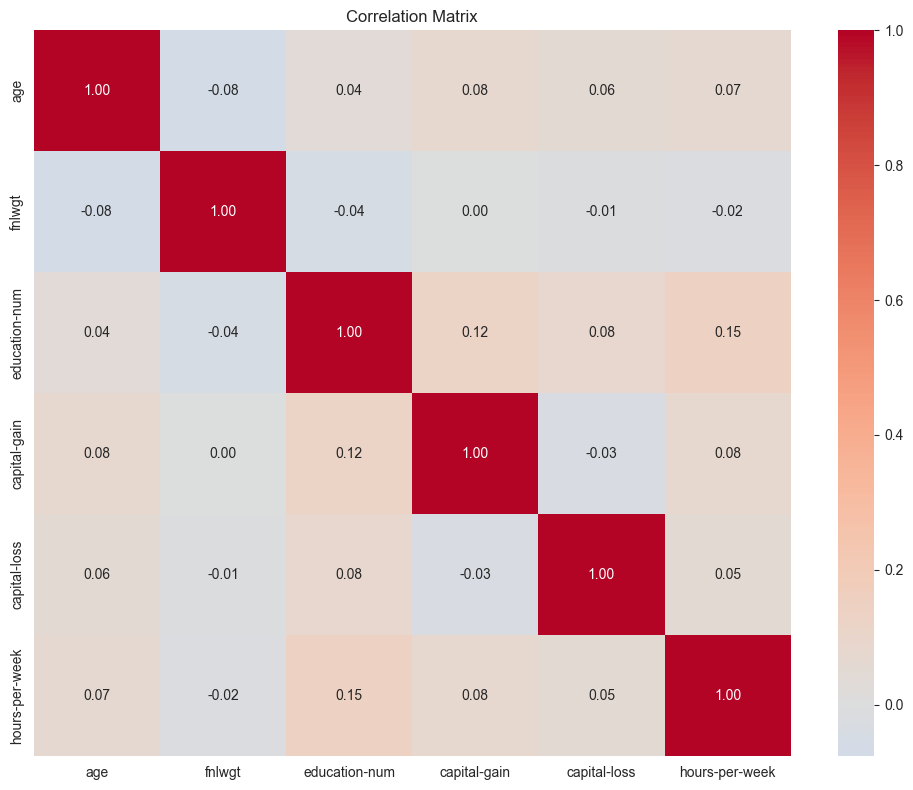

In [36]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

   *Your answer:* The target variable is binary and imbalanced. Roughly 75% of observations earn <= 50K and 25% earn >50K. This is a classification problem. Due to the imbalance, accuracy alone is misleading. I will report precision and recall along with the accuracy. 

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

   *Your answer:* Among numeric features, education-num shows the strongest correlations (0.15 with hours-per-week, 0.12 with capital-gain). No severe multicollinearity exists. All pairwise correlations are below 0.20. fnlwgt is essentially uncorrelated with all other features and will be dropped before modeling.

3. **What is the biggest data quality issue you found, and how will you handle it?**  

   *Your answer:* The biggest data quality issue was missing values in workclass and occupation (~5-6% of rows). This was handled by dropping affected rows, retaining 32,561 observations which is sufficient for modeling.

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 32561** observations and **M = 14** features.

**Missing data:** ~5.6% of cells are missing. The missingness pattern appears to be MAR because non-response in workclass and occupation. I will handle missing data by dropping affectd rows.

**Outliers:**  I identified outliers using Tukey Fences (k=1.5). Notable outliers exist in capital-gain (8.3%), capital-loss (4.7%), and hours-per-week (27.7%). I will handle them by keeping all outliers as-is, as they represent genuine economic variation rather than data errors.

**Target variable:** Binary and imbalanced: ~75% earn <=50K and ~25% earn >50K. Precision and recall will be reported alongside accuracy.

**Key finding from EDA:** Education is strongly associated with income class, and the dataset's class imbalance means accuracy alone is not a sufficient evaluation metric. 

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [37]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

# Encode categoricals, drop fnlwgt
cat_cols = ['workclass', 'education', 'marital-status', 'occupation',
            'relationship', 'race', 'sex', 'native-country']
df_model = pd.get_dummies(df.drop(columns=['fnlwgt']), columns=cat_cols, drop_first=True)

X = df_model.drop(columns=['income'])
y = (df_model['income'] == '>50K').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} samples')
print(f'Test:  {X_test.shape[0]} samples')

Train: 26048 samples
Test:  6513 samples


### 3.2 Model 1: Baseline

In [38]:
# ============================================================
# 3.2 Model 1 — Baseline
# ============================================================
model_1 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

model_1.fit(X_train, y_train)
y_pred_1 = model_1.predict(X_test)

print('Model 1: Logistic Regression')
print(classification_report(y_test, y_pred_1, target_names=['<=50K', '>50K']))

Model 1: Logistic Regression
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4945
        >50K       0.74      0.62      0.67      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.85      0.85      6513



In [40]:
import joblib
joblib.dump(model_1, '/Users/jakeeisner/Documents/econ3916/Files_From_Github/Final Project/model.pkl')
print('Model saved.')

Model saved.


### 3.3 Model 2: Your Choice

In [25]:
# ============================================================
# 3.3 Model 2 — Your choice
# ============================================================
from sklearn.ensemble import RandomForestClassifier

model_2 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
model_2.fit(X_train, y_train)
y_pred_2 = model_2.predict(X_test)

print('Model 2: Random Forest')
print(classification_report(y_test, y_pred_2, target_names=['<=50K', '>50K']))

Model 2: Random Forest
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      4945
        >50K       0.71      0.63      0.67      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.78      0.79      6513
weighted avg       0.84      0.85      0.85      6513



### 3.4 Cross-Validation Comparison

In [26]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

scoring = 'accuracy'

cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)

print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
    f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
})
comparison

Model 1 CV accuracy: 0.8500 +/- 0.0047
Model 2 CV accuracy: 0.8438 +/- 0.0041


,Model,CV accuracy (mean),CV accuracy (std)
0,Logistic Regression,0.850007,0.004717
1,Random Forest,0.843788,0.004118


---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

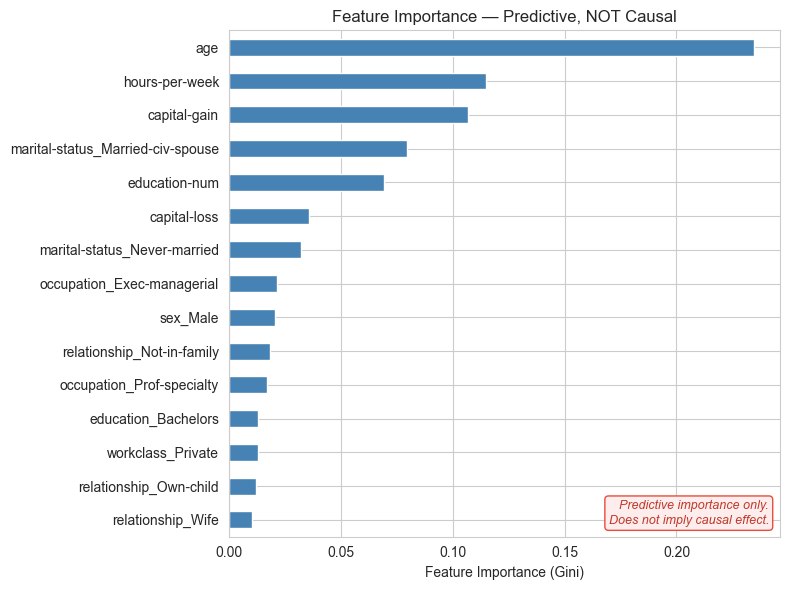

In [29]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

importances = pd.Series(
    model_2.feature_importances_, index=X.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance — Predictive, NOT Causal')

ax.text(
    0.98, 0.02,
    'Predictive importance only.\nDoes not imply causal effect.',
    transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
    style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
)

plt.tight_layout()
plt.show()

### 4.2 Key Visualization for Your Report

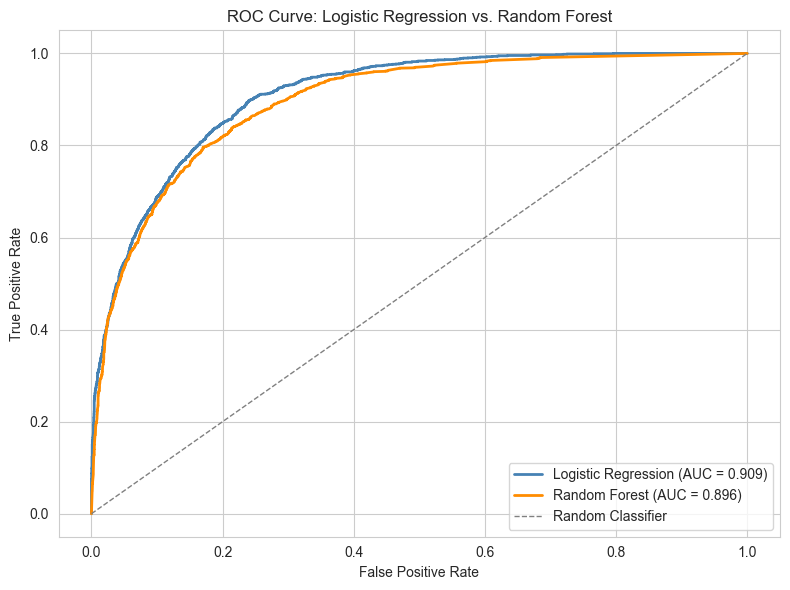

In [28]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

# YOUR CODE HERE
from sklearn.metrics import roc_curve, auc

y_prob_1 = model_1.predict_proba(X_test)[:, 1]
y_prob_2 = model_2.predict_proba(X_test)[:, 1]

fpr_1, tpr_1, _ = roc_curve(y_test, y_prob_1)
fpr_2, tpr_2, _ = roc_curve(y_test, y_prob_2)

auc_1 = auc(fpr_1, tpr_1)
auc_2 = auc(fpr_2, tpr_2)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_1, tpr_1, color='steelblue', lw=2, label=f'Logistic Regression (AUC = {auc_1:.3f})')
ax.plot(fpr_2, tpr_2, color='darkorange', lw=2, label=f'Random Forest (AUC = {auc_2:.3f})')
ax.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Logistic Regression vs. Random Forest')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** A consumer lender wants to identify applicants likely to earn more than $50,000 per year in order to extend pre-qualified loan offers before a full credit check, reducing underwriting costs while managing default risk.
(What is the context? Who is the stakeholder? What decision do they face?)

**Complication:** The target variable is imbalanced (~75% earn <=50K), making it easy to build a model that looks accurate but fails to identify high earners. The lender needs a model that reliably identifies the >50K class, not just one that predicts the majority class.
(What makes this decision hard? What uncertainty exists? What did your analysis reveal?)

**Resolution:** We recommend deploying the Logistic Regression model. It achieves AUC = 0.909, outperforming Random Forest (AUC = 0.896), and its linear structure makes predictions interpretable to loan officers. Age, hours worked per week, and capital gains activity are the strongest predictors of income class.
(What do you recommend? Based on what evidence? With what confidence?)

**Uncertainty Statement:**  Based on our cross-validation results (metric = accuracy = 0.850 +/- 0.005), we estimate that the model correctly classifies ~85% of applicants. The primary limitation is that the training data is from the 1994 Census and may not reflect current income distributions. We recommend using this model as a screening tool with the caveat that it should be recalibrated on more recent data before production deployment.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___